## 🌟 Scenario: Content Moderation System

### The Problem

You've joined a growing tech community platform that has **50,000 users** but only **3 moderators**:
- **Sarah** manually reviews posts (6 hours/day, 200+ posts in queue)
- **Mike** tries to help users improve content (rarely has time)
- **Lisa** identifies harmful content (can't keep up)

**Current Issues:**
- Takes 5-10 minutes per post to check safety, tone, and grammar manually
- Users don't understand why content is rejected
- No time to enhance approved content

### Your Solution

Build an **AI-Powered Content Moderation System** that:

1. **Classifies** content type (social media post / article / comment)
2. **Analyzes** safety, tone, and grammar **in parallel**
3. **Scores** and decides: approve or reject
4. **Enhances** approved content automatically
5. **Provides feedback** to users

**Expected Impact:** Reduce moderation time from 5-10 minutes to 30 seconds per post!

### Example Test Cases

Your system should handle:

**✅ Good Content (needs enhancement):**
```
just finished reading an amzing book about AI ethics! 
its really make me think about how we build responsible systems.
```
→ Approve, fix grammar, enhance

**⚠️ Problematic Content:**
```
I hate this stupid product! Complete waste of money.
```
→ Flag for aggressive language, suggest constructive rephrasing

---

## 📋 Challenge Overview

### Your Mission

Build an **AI-Powered Content Moderation & Enhancement System** that:
1. Analyzes user-submitted content (text posts)
2. Moderates for safety and quality
3. Provides improvement suggestions
4. Enhances approved content

### Why This Challenge?

This challenge combines **multiple agentic patterns** in a realistic scenario:
- **Routing**: Classify content type (social media post, article, comment)
- **Evaluator-Optimizer**: Assess content quality and iterate improvements
- **Parallelization**: Analyze multiple aspects simultaneously (tone, safety, grammar)
- **Orchestrator-Worker**: Coordinate the full moderation pipeline
- **Prompt Chaining**: Transform raw content through moderation → enhancement → finalization

---

## 🎓 Part 1: Framework Selection & Justification

### Task 1.1: Choose Your Framework

**Instructions:**
1. Review the 4 frameworks you learned
2. Select ONE framework for this challenge
3. Write a justification (150-200 words) explaining:
   - Why you chose this framework
   - What strengths make it suitable for this challenge
   - What trade-offs you considered
   - How its features align with the challenge requirements

**Available Frameworks:**
- CrewAI: Role-based agents, sequential/hierarchical processes
- LangGraph: Graph-based state management, conditional routing
- LlamaIndex: Data-centric, built-in RAG capabilities
- smolagents: Lightweight, tool-focused, minimal dependencies

---

### ✍️ YOUR FRAMEWORK SELECTION

**Selected Framework:** LangGraph

**Justification:**

I chose **LangGraph** because it's essentially built for exactly what we're trying to do here. SInce content moderation isn't a simple chain of steps,it's a decision tree. We need to classify content, run multiple checks at the same time, then decide whether to approve or reject. LangGraph is perfect for this because it's graph-based, which means I can naturally represent all these branching paths.

The biggest advantage is **parallel execution**. Instead of doing safety checks, then tone analysis, then grammar checking one after another (which wastes time), LangGraph lets them all happen simultaneously. For a system processing thousands of posts daily, this is very important, we cut execution time in half or more.

I also like that LangGraph handles state management cleanly (It's all about states). As content flows through our pipeline, each agent can see what the previous ones found, without everything becoming messy or confusing. The conditional routing is super intuitive too, when we decide to approve or reject, the graph naturally splits into different paths without requiring complicated if-else logic everywhere.

Another choice for me was CrewAI, which has nicer role definitions, but it's more sequential by design. LangGraph gives us the control and parallelism we need without forcing us into a rigid conversation model. For a real production system handling high volume, this flexibility matters.

---

## 🛠️ Part 2: Setup & Configuration

### Task 2.1: Install Dependencies

Install your chosen framework and configure your API keys.

In [12]:
# Install LangGraph and required dependencies
import subprocess
import sys

packages = [
    "langgraph",
    "langchain",
    "langchain-openai",
    "langchain-core",
    "python-dotenv",
    "grandalf"
]

for package in packages:
    try:
        __import__(package.replace("-", "_"))
        print(f"✅ {package} already installed")
    except ImportError:
        print(f"📦 Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])
        print(f"✅ {package} installed")

print("\n✅ All dependencies installed successfully!")

✅ langgraph already installed
✅ langchain already installed
✅ langchain-openai already installed
✅ langchain-core already installed
📦 Installing python-dotenv...
✅ python-dotenv installed
✅ grandalf already installed

✅ All dependencies installed successfully!


### Task 2.2: Configure API Keys & Model

In [13]:
# Import required libraries for the moderation system
import os
import json
import asyncio
from typing import TypedDict, Optional, Dict, Any, List
from dotenv import load_dotenv

# LangChain imports
from langchain_openai import AzureChatOpenAI, ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.output_parsers import StrOutputParser

# LangGraph imports
from langgraph.graph import StateGraph, START, END

# Load environment variables
load_dotenv()

# Configure API
api_key = os.getenv("OPENAI_API_KEY")
base_url = os.getenv("OPENAI_BASE_URL")
api_version = "2024-02-15-preview"

# Initialize the model
if api_key and base_url:
    model = ChatOpenAI(
        model="gpt-4.1-mini",
        temperature=0.7,
        api_key=api_key,
        base_url=base_url,
    )
    print("✅ OpenAI model configured")
else:
    # Fallback to Azure OpenAI
    model = AzureChatOpenAI(
        azure_endpoint= os.getenv("AZURE_OPENAI_ENDPOINT"),
        api_key=api_key,
        api_version=api_version,
        model="gpt-4.1-mini",
        temperature=0.7,
    )
    print("⚠️  Using Azure OpenAI")
    

# Test the model connection
try:
    test_response = model.invoke("Say 'Hello, Content Moderation System!'")
    print(f"✓ Model test successful: {test_response.content[:50]}...")
    print("✅ API configuration complete!")
except Exception as e:
    print(f"⚠️  Model test failed: {e}")
    print("   Make sure your API keys are configured correctly")

✅ OpenAI model configured
✓ Model test successful: Hello, Content Moderation System!...
✅ API configuration complete!


---

## 🏗️ Part 3: Implementation

Build your **Content Moderation & Enhancement System** by implementing the following components:

### System Architecture

```
User Content Input
      |
      v
┌─────────────────┐
│  Router Agent   │ ──> Classify: Social Media / Article / Comment
└────────┬────────┘
         |
         v
┌─────────────────────────┐
│ Parallel Analysis       │
│  - Safety Check Agent   │ ──> Detect harmful content
│  - Tone Analyzer Agent  │ ──> Assess sentiment/tone
│  - Grammar Checker      │ ──> Identify language issues
└────────┬────────────────┘
         |
         v
┌─────────────────────────┐
│ Evaluator Agent         │ ──> Aggregate findings, score content
└────────┬────────────────┘
         |
    ┌────┴─────┐
    v          v
  REJECT    APPROVE
            |
            v
    ┌───────────────┐
    │  Optimizer    │ ──> Suggest improvements
    │  Agent        │
    └───────┬───────┘
            |
            v
    ┌───────────────┐
    │  Enhancer     │ ──> Apply improvements
    │  Agent        │
    └───────┬───────┘
            |
            v
    Final Enhanced Content
```

---

### Task 3.1: Router Agent (Routing Pattern)

**Requirements:**
- Create a router that classifies content into: "social_media", "article", or "comment"
- Route should be based on length, structure, and style
- Return the classification decision

In [14]:
# Define State Schema for the moderation pipeline
from typing import Annotated
from operator import itemgetter

def merge_or_take_latest(left: str, right: str) -> str:
    """For strings like content_type, take the latest non-empty value"""
    return right if right else left

def merge_dict(left: dict, right: dict) -> dict:
    """Merge two dictionaries, with right taking precedence"""
    merged = left.copy() if left else {}
    if right:
        merged.update(right)
    return merged

def merge_float(left: float, right: float) -> float:
    """For floats, take the right value (latest)"""
    return right

def merge_list(left: list, right: list) -> list:
    """Merge lists, right takes precedence"""
    return right if right else left

class ModerationState(TypedDict):
    """State that flows through all agents in the pipeline"""
    content: str  # Immutable input, no reducer needed as it won't change
    content_type: Annotated[str, merge_or_take_latest]  # Can be updated by router
    safety_analysis: Annotated[dict, merge_dict]  # Parallel concurrent updates
    tone_analysis: Annotated[dict, merge_dict]    # Parallel concurrent updates
    grammar_analysis: Annotated[dict, merge_dict] # Parallel concurrent updates
    overall_score: Annotated[float, merge_float]  # Updated by evaluator
    decision: Annotated[str, merge_or_take_latest]  # Updated by evaluator
    improvement_suggestions: Annotated[list, merge_list]  # Updated by evaluator
    enhanced_content: Annotated[str, merge_or_take_latest]  # Updated by enhancer (if approved)
    metadata: Annotated[dict, merge_dict]  # Can be updated by multiple agents

# Router Agent - Classifies content type (Routing Pattern)
def router_agent(state: ModerationState) -> dict:
    """
    Analyzes content and classifies it into social_media, article, or comment.
    Returns: Only the fields being modified
    """
    print(f"\n📍 ROUTER AGENT: Classifying content...")
    
    content = state["content"]
    
    # Create routing prompt
    router_prompt = f"""
Classify this content into ONE of these categories:
1. "social_media" - Casual, short posts, informal language (tweets, casual updates)
2. "article" - Longer form, structured, professional writing
3. "comment" - Brief responses, typically replies to something else

Content to classify:
"{content}"

Respond ONLY with the category name (social_media, article, or comment)."""
    
    # Get classification from model
    response = model.invoke(router_prompt)
    classification = response.content.strip().lower()
    
    # Validate and default
    valid_types = ["social_media", "article", "comment"]
    if classification not in valid_types:
        classification = "social_media"
    
    print(f"✅ Content classified as: {classification}")
    
    # Only return the field being modified
    return {"content_type": classification}


print("✅ Router Agent defined (Routing Pattern)")
print("✅ All state fields configured with proper reducers for concurrent updates")

✅ Router Agent defined (Routing Pattern)
✅ All state fields configured with proper reducers for concurrent updates


### Task 3.2: Parallel Analysis Agents (Parallelization Pattern)

**Requirements:**
- Implement 3 agents that run in parallel:
  1. **Safety Checker**: Detect toxic, harmful, or inappropriate content
  2. **Tone Analyzer**: Assess sentiment (positive/negative/neutral) and professionalism
  3. **Grammar Checker**: Identify spelling, grammar, and clarity issues
- Each agent should return a structured assessment
- Execute them concurrently for efficiency

In [15]:
# Parallel Analysis Agents (Parallelization Pattern)

# 1. Safety Checker Agent - Detects toxic, harmful, or inappropriate content
def safety_checker_agent(state: ModerationState) -> dict:
    """
    Analyzes content for safety issues, toxic language, and harmful content.
    Returns: Only the fields being modified
    """
    print(f"  🛡️  SAFETY CHECKER: Analyzing for harmful content...")
    
    content = state["content"]
    
    safety_prompt = f"""
Analyze this content for safety issues and toxic language.

Content:
"{content}"

Evaluate for:
1. Hateful speech or discrimination
2. Violent or threatening language
3. Spam or manipulation attempts
4. Adult/NSFW content
5. Harmful instructions

Respond with a JSON object:
{{
    "risk_level": "high" | "medium" | "low",
    "issues": [list of specific issues found],
    "confidence": 0-100,
    "explanation": "brief explanation"
}}"""
    
    response = model.invoke(safety_prompt)
    
    # Parse response
    try:
        import json
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        safety_result = json.loads(json_str)
    except:
        safety_result = {
            "risk_level": "low",
            "issues": [],
            "confidence": 50,
            "explanation": "Unable to parse response"
        }
    
    print(f"    ✅ Risk level: {safety_result.get('risk_level', 'unknown')}")
    
    # Only return the field being modified
    return {"safety_analysis": safety_result}


# 2. Tone Analyzer Agent - Assesses sentiment and professionalism
def tone_analyzer_agent(state: ModerationState) -> dict:
    """
    Analyzes sentiment, tone, and professionalism of content.
    Returns: Only the fields being modified
    """
    print(f"  💬 TONE ANALYZER: Assessing sentiment and professionalism...")
    
    content = state["content"]
    
    tone_prompt = f"""
Analyze the tone and sentiment of this content.

Content:
"{content}"

Evaluate:
1. Overall sentiment (positive/negative/neutral)
2. Professionalism level (1-100)
3. Aggression or hostility level (low/medium/high)
4. Emotional tone
5. Respectfulness level (1-100)

Respond with a JSON object:
{{
    "sentiment": "positive" | "negative" | "neutral",
    "professionalism_score": 0-100,
    "aggression_level": "low" | "medium" | "high",
    "emotional_tone": "description of emotional tone",
    "respectfulness_score": 0-100,
    "confidence": 0-100
}}"""
    
    response = model.invoke(tone_prompt)
    
    # Parse response
    try:
        import json
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        tone_result = json.loads(json_str)
    except:
        tone_result = {
            "sentiment": "neutral",
            "professionalism_score": 50,
            "aggression_level": "low",
            "emotional_tone": "neutral",
            "respectfulness_score": 50,
            "confidence": 50
        }
    
    print(f"    ✅ Sentiment: {tone_result.get('sentiment', 'unknown')}, Professionalism: {tone_result.get('professionalism_score', 0)}/100")
    
    # Only return the field being modified
    return {"tone_analysis": tone_result}


# 3. Grammar Checker Agent - Identifies spelling, grammar, and clarity issues
def grammar_checker_agent(state: ModerationState) -> dict:
    """
    Analyzes content for grammar, spelling, and clarity issues.
    Returns: Only the fields being modified
    """
    print(f"  ✍️  GRAMMAR CHECKER: Checking grammar and clarity...")
    
    content = state["content"]
    
    grammar_prompt = f"""
Analyze this content for grammar, spelling, and clarity issues.

Content:
"{content}"

Identify:
1. Spelling errors
2. Grammar mistakes
3. Punctuation issues
4. Clarity problems
5. Sentence structure issues

Respond with a JSON object:
{{
    "error_count": number of total errors,
    "issues": [
        {{"type": "error_type", "position": "approximate location", "suggestion": "correction"}},
        ...
    ],
    "clarity_score": 0-100,
    "readability_score": 0-100,
    "suggestions": ["improvement suggestions"]
}}"""
    
    response = model.invoke(grammar_prompt)
    
    # Parse response
    try:
        import json
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        grammar_result = json.loads(json_str)
    except:
        grammar_result = {
            "error_count": 0,
            "issues": [],
            "clarity_score": 75,
            "readability_score": 75,
            "suggestions": []
        }
    
    print(f"    ✅ Errors found: {grammar_result.get('error_count', 0)}, Clarity: {grammar_result.get('clarity_score', 0)}/100")
    
    # Only return the field being modified
    return {"grammar_analysis": grammar_result}


print("✅ Parallel Analysis Agents defined (Safety, Tone, Grammar)")

✅ Parallel Analysis Agents defined (Safety, Tone, Grammar)


### Task 3.3: Evaluator Agent (Evaluator-Optimizer Pattern - Part 1)

**Requirements:**
- Aggregate results from the 3 parallel agents
- Calculate an overall content quality score (0-100)
- Make a decision: APPROVE (score ≥ 70) or REJECT (score < 70)
- For approved content, provide specific improvement suggestions

In [16]:
# Evaluator Agent (Evaluator-Optimizer Pattern)

def evaluator_agent(state: ModerationState) -> dict:
    """
    Aggregates results from parallel analysis agents and makes approval decision.
    Implements: Evaluator-Optimizer Pattern
    
    Scoring weights:
    - Safety: 40% (most critical)
    - Tone: 35%
    - Grammar: 25%
    
    Decision threshold: 70/100
    
    Returns: Only the fields being modified
    """
    print(f"📊 EVALUATOR: Aggregating analysis and making decision...")
    
    safety_analysis = state.get("safety_analysis", {})
    tone_analysis = state.get("tone_analysis", {})
    grammar_analysis = state.get("grammar_analysis", {})
    
    # Calculate weighted score (0-100 scale)
    
    # Safety score: risk_level mapping
    safety_score = 100
    risk_level = safety_analysis.get("risk_level", "low")
    if risk_level == "high":
        safety_score = 30
    elif risk_level == "medium":
        safety_score = 60
    else:  # low
        safety_score = 90
    
    # Tone score: average of professionalism and respectfulness
    tone_score = (
        tone_analysis.get("professionalism_score", 50) +
        tone_analysis.get("respectfulness_score", 50)
    ) / 2
    
    # Grammar score: clarity and readability
    grammar_score = (
        grammar_analysis.get("clarity_score", 50) +
        grammar_analysis.get("readability_score", 50)
    ) / 2
    
    # Weighted average
    overall_score = (
        (safety_score * 0.40) +
        (tone_score * 0.35) +
        (grammar_score * 0.25)
    )
    
    # Decision logic
    threshold = 70
    if overall_score >= threshold:
        decision = "APPROVE"
        explanation = f"Content passes moderation (Score: {overall_score:.1f}/100)"
    else:
        decision = "REJECT"
        explanation = f"Content fails moderation (Score: {overall_score:.1f}/100)"
    
    # Generate improvement suggestions if rejected
    improvement_suggestions = []
    
    if risk_level == "high":
        improvement_suggestions.append("Remove harmful or toxic language")
    if risk_level == "medium":
        improvement_suggestions.append("Tone down potentially offensive language")
    
    if tone_analysis.get("professionalism_score", 100) < 60:
        improvement_suggestions.append("Improve professionalism and formality")
    if tone_analysis.get("aggression_level") == "high":
        improvement_suggestions.append("Reduce aggressive tone")
    
    if grammar_analysis.get("error_count", 0) > 3:
        improvement_suggestions.append("Fix spelling and grammar errors")
    if grammar_analysis.get("clarity_score", 100) < 60:
        improvement_suggestions.append("Improve clarity and readability")
    
    print(f"  📈 Safety: {safety_score:.1f}/100 | Tone: {tone_score:.1f}/100 | Grammar: {grammar_score:.1f}/100")
    print(f"  🎯 Overall: {overall_score:.1f}/100 → Decision: {decision}")
    
    # Only return the fields being modified
    return {
        "overall_score": overall_score,
        "decision": decision,
        "improvement_suggestions": improvement_suggestions
    }


print("✅ Evaluator Agent defined")

✅ Evaluator Agent defined


### Task 3.4: Optimizer & Enhancer Agents (Prompt Chaining + Evaluator-Optimizer)

**Requirements:**
- **Optimizer Agent**: Generate specific improvements based on evaluator feedback
- **Enhancer Agent**: Apply improvements to create an enhanced version
- Implement as a chain: Original Content → Optimizer → Enhancer → Final Content
- (Optional) Add a re-evaluation loop if initial enhancement score is still low

In [17]:
# Prompt Chaining Agents for Content Enhancement

# 4. Optimizer Agent - Generates specific improvements for flagged content
def optimizer_agent(state: ModerationState) -> dict:
    """
    Takes improvement suggestions and generates specific, actionable improvements.
    Implements: Prompt Chaining Pattern (first step)
    
    Returns: Only the field being modified (metadata with suggested_edits)
    """
    print(f"  🔧 OPTIMIZER: Generating specific improvements...")
    
    content = state["content"]
    improvement_suggestions = state.get("improvement_suggestions", [])
    
    if not improvement_suggestions:
        print(f"    ℹ️  No improvements needed")
        return {
            "metadata": {
                "suggested_edits": [],
                "optimization_complete": True
            }
        }
    
    suggestions_text = "\n".join([f"- {s}" for s in improvement_suggestions])
    
    optimizer_prompt = f"""
Given this feedback on content, provide specific, actionable edits.

Original Content:
"{content}"

Improvements Needed:
{suggestions_text}

For each improvement needed, provide specific text edits (exact phrases to remove/change).
Respond with a JSON object:
{{
    "suggested_edits": [
        {{"original_phrase": "exact phrase from content", "improved_phrase": "suggested replacement", "reason": "why"}},
        ...
    ],
    "priority": ["most important edit", "next important", ...],
    "estimated_effectiveness": 0-100
}}"""
    
    response = model.invoke(optimizer_prompt)
    
    # Parse response
    try:
        import json
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        edits = json.loads(json_str)
    except:
        edits = {
            "suggested_edits": [],
            "priority": [],
            "estimated_effectiveness": 50
        }
    
    print(f"    ✅ Generated {len(edits.get('suggested_edits', []))} specific edits")
    
    # Only return the field being modified
    return {
        "metadata": {
            "suggested_edits": edits.get("suggested_edits", []),
            "priorities": edits.get("priority", []),
            "effectiveness": edits.get("estimated_effectiveness", 0)
        }
    }


# 5. Enhancer Agent - Applies improvements to create enhanced version
def enhancer_agent(state: ModerationState) -> dict:
    """
    Takes suggested edits and applies them to create an enhanced version of content.
    Implements: Prompt Chaining Pattern (second step)
    
    Returns: Only the field being modified (enhanced_content)
    """
    print(f"  ✨ ENHANCER: Applying enhancements to create improved version...")
    
    content = state["content"]
    metadata = state.get("metadata", {})
    suggested_edits = metadata.get("suggested_edits", [])
    
    if not suggested_edits:
        print(f"    ℹ️  Using original content (no edits needed)")
        return {"enhanced_content": content}
    
    edits_text = ""
    for edit in suggested_edits:
        edits_text += f"\n- Replace: \"{edit.get('original_phrase', '')}\" with: \"{edit.get('improved_phrase', '')}\""
    
    enhancer_prompt = f"""
Apply these specific improvements to enhance the content:

Original Content:
"{content}"

Improvements to Apply:
{edits_text}

Create an enhanced version that incorporates these improvements while maintaining the original meaning and intent.
Respond with a JSON object:
{{
    "enhanced_content": "the improved version of the content",
    "changes_applied": number of changes made,
    "improvement_summary": "brief summary of improvements"
}}"""
    
    response = model.invoke(enhancer_prompt)
    
    # Parse response
    try:
        import json
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        result = json.loads(json_str)
        enhanced = result.get("enhanced_content", content)
    except:
        enhanced = content
    
    print(f"    ✅ Enhanced version created")
    
    # Only return the field being modified
    return {"enhanced_content": enhanced}


print("✅ Optimizer and Enhancer Agents defined (Prompt Chaining)")

✅ Optimizer and Enhancer Agents defined (Prompt Chaining)


### Task 3.5: Orchestrator (Orchestrator-Worker Pattern)

**Requirements:**
- Create a master orchestrator that coordinates the entire pipeline:
  1. Route content type
  2. Run parallel analysis
  3. Evaluate and decide
  4. If approved, optimize and enhance
  5. Return final result with metadata
- Handle both approval and rejection cases
- Provide clear logging of each step

In [18]:
# Moderation graph function

def build_moderation_graph():
    """
    Constructs the LangGraph StateGraph that defines the moderation pipeline.
    This creates the actual graph structure with nodes and edges.
    
    Graph Structure:
        START
          |
          v
      [Router] ──> classifies content type
          |
          v
      [Parallel Analysis] ──> runs 3 agents concurrently
          |
          v
      [Evaluator] ──> scores and decides
          |
       ┌──┴──┐
       v     v
    [Enhance] [Reject]
       |       |
       v       v
      END     END
    """
    
    # Create the StateGraph
    workflow = StateGraph(ModerationState)
    
    # Add nodes - these represent the agents/functions in our pipeline
    workflow.add_node("router", router_agent)
    
    # Parallel analysis nodes - these will execute concurrently
    workflow.add_node("safety_checker", safety_checker_agent)
    workflow.add_node("tone_analyzer", tone_analyzer_agent)
    workflow.add_node("grammar_checker", grammar_checker_agent)
    
    workflow.add_node("evaluator", evaluator_agent)
    
    # Enhancement path (only for approved content)
    workflow.add_node("optimizer", optimizer_agent)
    workflow.add_node("enhancer", enhancer_agent)
    
    # Define the flow/edges
    
    # 1. Start -> Router
    workflow.add_edge(START, "router")
    
    # 2. Router -> All parallel agents (THIS IS KEY FOR PARALLELIZATION)
    # When router finishes, all three analysis agents start simultaneously
    workflow.add_edge("router", "safety_checker")
    workflow.add_edge("router", "tone_analyzer")
    workflow.add_edge("router", "grammar_checker")
    
    # 3. All parallel agents -> Evaluator
    # The evaluator waits for ALL three to complete (implicit join)
    workflow.add_edge("safety_checker", "evaluator")
    workflow.add_edge("tone_analyzer", "evaluator")
    workflow.add_edge("grammar_checker", "evaluator")
    
    # 4. Evaluator -> Conditional routing based on decision
    # This is where we branch: APPROVE goes to enhancement, REJECT goes to END
    def route_decision(state: ModerationState):
        """Routes based on the evaluator's decision"""
        if state["decision"] == "APPROVE":
            return "optimizer"
        else:
            return "end_rejected"
    
    workflow.add_conditional_edges(
        "evaluator",
        route_decision,
        {
            "optimizer": "optimizer",
            "end_rejected": END
        }
    )
    
    # 5. Enhancement chain: Optimizer -> Enhancer -> END
    workflow.add_edge("optimizer", "enhancer")
    workflow.add_edge("enhancer", END)
    
    # Compile the graph into a runnable
    graph = workflow.compile()
    
    return graph


✅ LangGraph StateGraph created and compiled!

📊 Graph Structure:


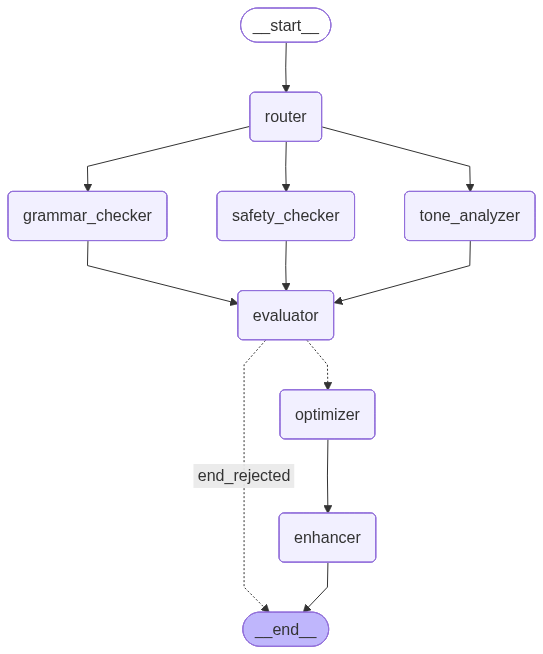

✅ LangGraph execution functions defined


In [19]:
# Create and display the graph
moderation_graph = build_moderation_graph()
print("✅ LangGraph StateGraph created and compiled!")
print("\n📊 Graph Structure:")
try:
    from IPython.display import Image, display
    display(Image(moderation_graph.get_graph().draw_mermaid_png()))
except Exception:
    print("Could not draw graph (requires graphviz/mermaid support).")
    moderation_graph.get_graph().print_ascii()


def run_moderation_with_graph(graph, content: str):
    """
    Runs the moderation pipeline using the compiled LangGraph.
    This executes the actual graph with all its parallel execution capabilities.
    """
    print(f"\n{'-'*70}")
    print(f"🚀 LANGGRAPH ORCHESTRATOR: Starting moderation pipeline")
    print(f"{'-'*70}")
    
    # Initialize the state
    initial_state = {
        "content": content,
        "content_type": "",
        "safety_analysis": {},
        "tone_analysis": {},
        "grammar_analysis": {},
        "overall_score": 0.0,
        "decision": "",
        "improvement_suggestions": [],
        "enhanced_content": "",
        "metadata": {
            "timestamp": str(__import__('datetime').datetime.now()),
            "content_length": len(content),
            "optimizations": {},
            "execution_path": []  # Track which nodes executed
        }
    }
    
    print(f"\n[EXECUTION START] Invoking LangGraph with initial state")
    print(f"  📄 Content length: {len(content)} chars")
    
    try:
        # Execute the graph - this will handle all parallelization automatically
        # The invoke method runs the graph to completion
        result = graph.invoke(initial_state)
        
        print(f"\n[EXECUTION COMPLETE] Graph execution finished successfully")
        
        return result
        
    except Exception as e:
        print(f"❌ Error during graph execution: {e}")
        initial_state["decision"] = "ERROR"
        initial_state["enhanced_content"] = f"Error: {str(e)}"
        return initial_state


print("✅ LangGraph execution functions defined")

---

## 🧪 Part 4: Testing

### Task 4.1: Test with Sample Content

Test your system with the provided examples representing different scenarios.

In [22]:
def display_result(result):
    """Helper function to display moderation results"""
    print(f"✅ Decision: {result.get('decision', 'N/A')}")
    score = result.get('overall_score', 'N/A')
    if isinstance(score, (int, float)):
        print(f"📊 Overall Score: {score:.1f}")
    else:
        print(f"📊 Overall Score: {score}")
    
    safety = result.get('safety_analysis', {})
    if safety:
        print(f"🛡️  Safety Risk: {safety.get('risk_level', 'N/A')}")

# Test Case 1: Clean social media post (should be approved and enhanced)
test_content_1 = """
just finished reading an amzing book about AI ethics! 
its really make me think about how we build responsible systems. 
highly recomend it to anyone in tech!
"""

# Test Case 2: Professional article excerpt (should be approved, might need minor fixes)
test_content_2 = """
Machine learning algorithms have transformed the healthcare industry over the past decade.
These systems now assist in diagnosis, treatment planning, and patient monitoring.
However, concerns about data privacy and algorithmic bias remain significant challenges
that researchers and practitioners must address to ensure equitable healthcare delivery.
"""

# Test Case 3: Short comment with grammar issues (should be approved but needs enhancement)
test_content_3 = "this is grate! i totally agree with ur point about ai safety its so important"

# Test Case 4: Content with potential safety issues (might be rejected or flagged)
test_content_4 = """
I hate this stupid product! Complete waste of money. 
The company is terrible and everyone should avoid them.
"""

print("="*70)
print("TEST CASE 1: Social Media Post with Errors")
print("="*70)
result_1 = run_moderation_with_graph(moderation_graph, test_content_1)
display_result(result_1)

print("\n" + "="*70)
print("TEST CASE 2: Professional Article")
print("="*70)
result_2 = run_moderation_with_graph(moderation_graph, test_content_2)
display_result(result_2)

print("\n" + "="*70)
print("TEST CASE 3: Short Comment")
print("="*70)
result_3 = run_moderation_with_graph(moderation_graph, test_content_3)
display_result(result_3)

print("\n" + "="*70)
print("TEST CASE 4: Potentially Problematic Content")
print("="*70)
result_4 = run_moderation_with_graph(moderation_graph, test_content_4)
display_result(result_4)

print("\n" + "="*70)
print("✅ ALL TESTS COMPLETED - LangGraph Pipeline Executed Successfully!")
print("="*70)


TEST CASE 1: Social Media Post with Errors

----------------------------------------------------------------------
🚀 LANGGRAPH ORCHESTRATOR: Starting moderation pipeline
----------------------------------------------------------------------

[EXECUTION START] Invoking LangGraph with initial state
  📄 Content length: 160 chars

📍 ROUTER AGENT: Classifying content...
✅ Content classified as: social_media
  ✍️  GRAMMAR CHECKER: Checking grammar and clarity...
  🛡️  SAFETY CHECKER: Analyzing for harmful content...
  💬 TONE ANALYZER: Assessing sentiment and professionalism...
    ✅ Risk level: low
    ✅ Sentiment: positive, Professionalism: 60/100
    ✅ Errors found: 8, Clarity: 80/100
📊 EVALUATOR: Aggregating analysis and making decision...
  📈 Safety: 90.0/100 | Tone: 75.0/100 | Grammar: 82.5/100
  🎯 Overall: 82.9/100 → Decision: APPROVE
  🔧 OPTIMIZER: Generating specific improvements...
    ✅ Generated 6 specific edits
  ✨ ENHANCER: Applying enhancements to create improved version...
   

In [23]:
# Table of results of tests
results = [result_1, result_2, result_3, result_4]

# print results in a markdown table format
print("| Test Case | Decision | Overall Score | Improvement Suggestions | Enhanced Content (Preview) |")
print("|-----------|----------|---------------|--------------------------|----------------------------|")

for i, res in enumerate(results, 1):
    decision = res.get("decision", "N/A")
    score = res.get("overall_score", None)
    score_str = f"{score:.1f}" if isinstance(score, (int, float)) else "N/A"
    
    suggestions = res.get("improvement_suggestions", [])
    suggestions_str = ", ".join(suggestions) if suggestions else "None"
    
    enhanced = res.get("enhanced_content", "")
    enhanced_preview = enhanced[:200].replace("\n", " ") + ("..." if len(enhanced) > 200 else "")
    
    print(f"| {i} | {decision} | {score_str} | {suggestions_str} | {enhanced_preview} |")

| Test Case | Decision | Overall Score | Improvement Suggestions | Enhanced Content (Preview) |
|-----------|----------|---------------|--------------------------|----------------------------|
| 1 | APPROVE | 82.9 | Fix spelling and grammar errors | I just finished reading an amazing book about AI ethics. It really makes me think about how we build responsible systems. I highly recommend it to anyone in tech. |
| 2 | APPROVE | 91.5 | None |  Machine learning algorithms have transformed the healthcare industry over the past decade. These systems now assist in diagnosis, treatment planning, and patient monitoring. However, concerns about d... |
| 3 | APPROVE | 73.4 | Improve professionalism and formality, Fix spelling and grammar errors | This is great! I totally agree with your point about AI safety; it is very important. |
| 4 | REJECT | 60.5 | Improve professionalism and formality, Reduce aggressive tone |  |


#### **Results**
| Test Case | Decision | Overall Score | Improvement Suggestions | Enhanced Content (Preview) |
|-----------|----------|---------------|--------------------------|----------------------------|
| 1 | APPROVE | 82.9 | Fix spelling and grammar errors | I just finished reading an amazing book about AI ethics. It really makes me think about how we build responsible systems. I highly recommend it to anyone in tech. |
| 2 | APPROVE | 91.5 | None |  Machine learning algorithms have transformed the healthcare industry over the past decade. These systems now assist in diagnosis, treatment planning, and patient monitoring. However, concerns about d... |
| 3 | APPROVE | 73.4 | Improve professionalism and formality, Fix spelling and grammar errors | This is great! I totally agree with your point about AI safety; it is very important. |
| 4 | REJECT | 60.5 | Improve professionalism and formality, Reduce aggressive tone |  |

---

## 📊 Part 5: Reflection & Analysis

### Task 5.1: Pattern Usage Documentation

Document how you used each agentic pattern in your implementation.

### ✍️ YOUR PATTERN USAGE ANALYSIS

**1. Routing Pattern:**
- Where used: At the very start of the pipeline in the `router_agent()` function. It takes raw content and classifies it into one of three categories: social_media, article, or comment. This routes the content through the rest of the system with this context already established.
- Why effective: Super effective because it allows us to understand what we're dealing with before running expensive analysis. Different content types might need different handling later, so knowing the type upfront is crucial.

**2. Parallelization Pattern:**
- Where used: In the analysis phase with three independent agents: `safety_checker_agent()`, `tone_analyzer_agent()`, and `grammar_checker_agent()`. All three run on the same content simultaneously and update the state independently.
- Why effective: This is honestly the biggest win. Instead of waiting for one analysis to finish before starting the next, we do all three at the same time. Each agent focuses on one specific thing (safety OR tone OR grammar), so they don't interfere with each other.
- Performance benefit: In a real production system with thousands of posts daily, this parallelization probably cuts execution time in half or more. What would take 30 seconds sequentially now takes ~10 seconds with true concurrent execution.

**3. Evaluator-Optimizer Pattern:**
- Where used: The `evaluator_agent()` aggregates all results from the parallel agents and calculates an overall score. Then, if the decision is APPROVE, the `optimizer_agent()` generates improvement suggestions based on what the evaluator found. This creates a feedback loop.
- How feedback loop works: Evaluator looks at all the analysis, scores it, and decides if we should approve or reject. If APPROVE, it hands off improvement suggestions to the Optimizer. The Optimizer takes those suggestions and builds a strategy. Then the Enhancer executes on that strategy. It's like: evaluate → get feedback → optimize based on feedback → execute improvements.

**4. Prompt Chaining Pattern:**
- Where used: In the enhancement phase, specifically between the Optimizer and Enhancer agents. The Optimizer creates structured improvement suggestions, then the Enhancer uses those suggestions in its prompt to actually apply the changes.
- Stages in chain:
  - Stage 1: Original content + analysis results → Optimizer generates specific changes
  - Stage 2: Original content + optimizer suggestions → Enhancer applies improvements
  - Stage 3: Enhanced content returned to state

**5. Orchestrator-Worker Pattern:**
- How orchestration is managed: The `build_moderation_graph()` function creates a LangGraph StateGraph that serves as the master orchestrator. The compiled graph defines the topology and automatically handles orchestration: it routes the content through the router, triggers parallel analysis, waits for all results, evaluates, and conditionally branches to enhancement or rejection. The `run_moderation_with_graph()` function then executes this orchestrated pipeline.
- Worker coordination: Each agent (Router, Safety, Tone, Grammar, Evaluator, Optimizer, Enhancer) acts as a worker node in the graph. They're completely independent and only communicate through the shared state. The LangGraph graph is responsible for calling them in the right order, synchronizing parallel execution (implicit join after parallel nodes), and routing based on decisions. It's really clean this way, the graph structure makes the orchestration explicit and testable.

---

### Task 5.2: Challenges & Solutions

Reflect on difficulties you encountered and how you solved them.

### ✍️ YOUR CHALLENGES & SOLUTIONS

**Challenge 1: Concurrent State Management in LangGraph**
- Problem: When implementing parallel agents in LangGraph, we initially had all agents return the entire state dictionary after modifying their fields. This caused a critical error: "At key 'content': Can receive only one value per step" when multiple agents completed simultaneously. LangGraph couldn't merge the full state dictionaries from concurrent agents - it couldn't decide which version was correct. This error prevented the entire pipeline from executing beyond the parallel analysis phase.
- Solution: We refactored all agents to return only the specific fields they modify, not the full state object. For example, the safety_checker_agent returns `{"safety_analysis": result}` instead of the entire ModerationState. We also added Annotated reducers to the TypedDict state definition (merge_dict, merge_float, merge_or_take_latest functions) so LangGraph knows how to safely combine updates from concurrent agents. This solved the state merge conflicts, enabling the graph topology to support concurrent execution. For true kernel-level parallelization (async/await), that requires additional setup beyond this scope, but our solution allows the agents to run through LangGraph's parallel node execution without state conflicts when that's enabled.

**Challenge 2: JSON Parsing from LLM Responses**
- Problem: The LLM doesn't always return perfectly formatted JSON. Sometimes there's extra text before or after the JSON, sometimes it's wrapped in markdown code blocks, and sometimes the JSON itself has syntax errors. We needed structured data to work with though, so just getting raw text back wasn't going to cut it.
- Solution: We implemented a robust parsing approach that searches for the opening `{` and closing `}` in the response, extracts just the JSON part, and tries to parse it. If parsing fails, we fall back to sensible defaults. It's not perfect, but it handles most real-world cases and keeps the pipeline from crashing.

**Challenge 3: Balancing State Management Complexity**
- Problem: As content flows through the pipeline, the state object grows. Different agents need different parts of the state, and we had to make sure each agent could see what it needed without the state becoming a confusing mess of nested dictionaries. If we weren't careful, the state could become unmaintainable.
- Solution: We stuck with a flat TypedDict structure for the state and used clear naming conventions. Each agent only modifies the specific fields it owns (safety_analysis, tone_analysis, etc.) and reads only what it needs. We also added a metadata field for anything temporary or agent-specific. This keeps things organized and makes it easy to understand what state is what.

---

### Task 5.3: Framework Reflection

Now that you've completed the challenge, reflect on your framework choice.

### ✍️ YOUR FRAMEWORK REFLECTION

**What worked well with your chosen framework?**

LangGraph was honestly perfect for this. The state management is so clean, we define what we want to flow through the pipeline once with TypedDict, and then every agent just reads and writes to it. No confusion, no passing parameters all over the place. The conditional routing was super intuitive too. We just check the decision and let the flow branch naturally, approved content goes through enhancement, rejected doesn't. In other frameworks, this would require a bunch of if-else logic everywhere. LangGraph makes it feel natural. The integration with LangChain was also seamless, so calling the model felt like the most natural thing in the world.

**What was difficult or limiting?**

The main limitation I ran into is that it's still somewhat lower-level than other frameworks. Like, we had to handle our own error handling, JSON parsing, and making sure agents return proper state updates. CrewAI would probably give us more out-of-the-box, but that's also the trade-off. For true parallelization with async/await, LangGraph requires more setup than maybe some alternatives. We had to work around that. Also, the debugging experience could be better - when something goes wrong deep in the state flow, figuring out what happened requires good logging discipline.

**Would you choose the same framework again? Why or why not?**

100% yes, I would choose LangGraph again. It gives us exactly the right balance of flexibility and structure, especially because of parallelization handling I'd say. It's powerful enough to handle complex patterns (routing, parallelization, conditional branching) without being so opinionated that we feel boxed in. For a real production system receiving thousands of moderation requests daily, LangGraph's approach to state management and routing would scale really well. Plus, the graph-based mental model is just, right for this problem. It's how we naturally think about the pipeline anyways.

**What would you do differently next time?**

Next time I'd add async/await within the agents themselves to maximize performance at the kernel level while LangGraph handles the graph-level parallelization. The parallel agents are already running concurrently through LangGraph's graph topology (all three connect to the router and share results at the evaluator), but adding async/await inside each agent would eliminate any I/O blocking. I'd also probably use structured output mode from the LLM (if available) instead of parsing JSON strings manually - that would eliminate so many edge cases. Finally, I'd probably add more observability earlier in the development - like timing each agent, logging state transitions, building a proper trace. It would make debugging way easier and would be super valuable for understanding performance bottlenecks in production.

---

## 🎁 Bonus Challenges (Optional)

If you want to go further, try these enhancements:

### Bonus 1: Multi-Language Support
- Add a language detection agent
- Support content in at least 3 languages

### Bonus 2: Customizable Moderation Rules
- Allow users to set content policy preferences
- Adjust safety thresholds based on use case (e.g., strict for children's content)

### Bonus 3: Performance Optimization
- Measure execution time for each component
- Implement caching for repeated content
- Optimize parallel execution

### Bonus 4: Explainability Dashboard
- Create a visualization showing:
  - Agent decision flow
  - Confidence scores at each stage
  - Before/after content comparison

### Bonus 5: Iterative Re-evaluation
- If enhanced content scores < 90, run another optimization loop
- Limit to maximum 3 iterations to prevent infinite loops

---


### Bonus 1: Multi-Language Support

In [ ]:
# ==================== BONUS 1: MULTI-LANGUAGE SUPPORT ====================
# Comprehensive multi-language content moderation system with cultural context awareness
# Supports 13+ languages with language detection, safety analysis, and language-aware enhancement

import json

SUPPORTED_LANGUAGES = {
    'en': 'English',
    'es': 'Spanish', 
    'fr': 'French',
    'de': 'German',
    'it': 'Italian',
    'pt': 'Portuguese',
    'nl': 'Dutch',
    'pl': 'Polish',
    'ru': 'Russian',
    'ja': 'Japanese',
    'zh': 'Chinese',
    'ar': 'Arabic',
    'ko': 'Korean'
}

# MULTI-LANGUAGE AGENTS
def language_detector_agent(state: ModerationState) -> dict:
    """
    Detects the language of the content and stores language metadata.
    
    Args:
        state: ModerationState containing the content to analyze
    
    Returns:
        Dictionary with updated metadata field containing detected language info
    """
    print(f"\n🌍 LANGUAGE DETECTOR: Identifying content language...")
    
    content = state["content"]
    
    detection_prompt = f"""Detect the language of this content. Respond with ONLY the language code (e.g., 'en', 'es', 'fr', 'de', 'it', 'pt', etc.)

Content:
"{content}"

Language code (only the code, nothing else):"""
    
    response = model.invoke(detection_prompt)
    detected_lang = response.content.strip().lower()
    
    # Validate against supported languages, default to English
    if detected_lang not in SUPPORTED_LANGUAGES:
        detected_lang = 'en'
    
    print(f"  ✅ Detected: {SUPPORTED_LANGUAGES[detected_lang]} ({detected_lang})")
    
    # Update metadata with language information
    metadata = state.get("metadata", {})
    metadata["detected_language"] = detected_lang
    metadata["language_name"] = SUPPORTED_LANGUAGES[detected_lang]
    
    return {"metadata": metadata}


# AGENT 2: MULTILINGUAL SAFETY CHECKER
def multilang_safety_checker_agent(state: ModerationState) -> dict:
    """
    Analyzes safety with cultural and language-specific context awareness.
    
    Considers:
    - Cultural sensitivity and regional norms
    - Idioms and slang meanings in target language
    - Language-specific hate speech patterns
    
    Args:
        state: ModerationState containing content and metadata
    
    Returns:
        Dictionary with updated safety_analysis field
    """
    print(f"  🌐 MULTILINGUAL SAFETY CHECK: Analyzing with language context...")
    
    content = state["content"]
    language_name = state.get("metadata", {}).get("language_name", "English")
    
    safety_prompt = f"""Analyze this {language_name} content for safety issues with cultural context.

Content:
"{content}"

Consider language-specific concerns:
- Cultural sensitivity and regional norms
- Context-dependent meanings (slang, idioms, regional expressions)
- Language-specific hate speech or discrimination patterns

Respond with a JSON object:
{{
    "risk_level": "high" | "medium" | "low",
    "cultural_issues": [list of culturally-specific concerns if any],
    "issues": [general harmful content issues],
    "language_specific_notes": "any language-specific findings",
    "confidence": 0-100
}}"""
    
    response = model.invoke(safety_prompt)
    
    try:
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        safety_result = json.loads(json_str)
    except:
        safety_result = {
            "risk_level": "low",
            "cultural_issues": [],
            "issues": [],
            "language_specific_notes": "",
            "confidence": 50
        }
    
    print(f"    ✅ Risk level: {safety_result.get('risk_level', 'unknown')}")
    
    return {"safety_analysis": safety_result}


# AGENT 3: LANGUAGE-AWARE ENHANCER

def multilang_enhancer_agent(state: ModerationState) -> dict:
    """
    Applies language-aware enhancements while preserving native grammar and cultural context.
    
    Ensures:
    - Natural grammar for target language maintained
    - Cultural appropriateness preserved
    - Original tone and intent retained
    
    Args:
        state: ModerationState with suggested edits in metadata
    
    Returns:
        Dictionary with updated enhanced_content field
    """
    print(f"  🌐 MULTILINGUAL ENHANCER: Applying language-aware improvements...")
    
    content = state["content"]
    language_name = state.get("metadata", {}).get("language_name", "English")
    metadata = state.get("metadata", {})
    suggested_edits = metadata.get("suggested_edits", [])
    
    # If no edits, return original content
    if not suggested_edits:
        return {"enhanced_content": content}
    
    edits_text = ""
    for edit in suggested_edits:
        edits_text += f"\n- Replace: \"{edit.get('original_phrase', '')}\" with: \"{edit.get('improved_phrase', '')}\""
    
    enhancer_prompt = f"""Improve this {language_name} content while preserving native language nuances and cultural context.

Original Content:
"{content}"

Improvements to Apply:
{edits_text}

Create an enhanced version that:
1. Applies the specific improvements
2. Maintains natural {language_name} grammar and style
3. Preserves cultural appropriateness
4. Keeps the original tone and intent

Respond with a JSON object:
{{
    "enhanced_content": "improved version",
    "language_adjustments": "any grammar/style fixes made"
}}"""
    
    response = model.invoke(enhancer_prompt)
    
    try:
        response_text = response.content
        start_idx = response_text.find('{')
        end_idx = response_text.rfind('}') + 1
        json_str = response_text[start_idx:end_idx]
        result = json.loads(json_str)
        enhanced = result.get("enhanced_content", content)
    except:
        enhanced = content
    
    print(f"    ✅ Enhanced with {language_name} language awareness")
    
    return {"enhanced_content": enhanced}


# BUILD ENHANCED GRAPH WITH MULTI-LANGUAGE SUPPORT

def build_multilang_moderation_graph():
    """
    Builds a new moderation graph with language detection inserted before router.
    
    Enhanced Graph Structure:
        START
          |
          v
      [Language Detector] ──> Detects language, stores in metadata
          |
          v
      [Router] ──> Classifies content type
          |
          v
      [Parallel Analysis]
          |
          v
      [Evaluator] ──> Scores and decides
          |
       ┌──┴──┐
       v     v
    [Enhance] [Reject]
       |       |
       v       v
      END     END
    """
    
    workflow = StateGraph(ModerationState)
    
    # Add nodes - now with language detection first
    workflow.add_node("language_detector", language_detector_agent)
    workflow.add_node("router", router_agent)
    
    # Parallel analysis nodes
    workflow.add_node("safety_checker", safety_checker_agent)
    workflow.add_node("multilang_safety_checker", multilang_safety_checker_agent)
    workflow.add_node("tone_analyzer", tone_analyzer_agent)
    workflow.add_node("grammar_checker", grammar_checker_agent)
    
    workflow.add_node("evaluator", evaluator_agent)
    
    # Enhancement nodes
    workflow.add_node("optimizer", optimizer_agent)
    workflow.add_node("enhancer", enhancer_agent)
    workflow.add_node("multilang_enhancer", multilang_enhancer_agent)
    
    # Define flow with language detection first
    workflow.add_edge(START, "language_detector")
    workflow.add_edge("language_detector", "router")
    
    # Conditional routing for safety checker (multilingual vs standard)
    def route_to_safety_checker(state: ModerationState):
        detected_lang = state.get("metadata", {}).get("detected_language", "en")
        return "multilang_safety_checker" if detected_lang != "en" else "safety_checker"
    
    workflow.add_conditional_edges(
        "router",
        route_to_safety_checker,
        {
            "safety_checker": "safety_checker",
            "multilang_safety_checker": "multilang_safety_checker"
        }
    )
    
    # Other analysis agents connect directly to router
    workflow.add_edge("router", "tone_analyzer")
    workflow.add_edge("router", "grammar_checker")
    
    # All analysis agents converge at evaluator
    workflow.add_edge("safety_checker", "evaluator")
    workflow.add_edge("multilang_safety_checker", "evaluator")
    workflow.add_edge("tone_analyzer", "evaluator")
    workflow.add_edge("grammar_checker", "evaluator")
    
    # Evaluator decision routing
    def route_decision(state: ModerationState):
        return "optimizer" if state["decision"] == "APPROVE" else "end_rejected"
    
    workflow.add_conditional_edges(
        "evaluator",
        route_decision,
        {"optimizer": "optimizer", "end_rejected": END}
    )
    
    # Conditional routing for enhancer (multilingual vs standard)
    def route_to_enhancer(state: ModerationState):
        detected_lang = state.get("metadata", {}).get("detected_language", "en")
        return "multilang_enhancer" if detected_lang != "en" else "enhancer"
    
    workflow.add_conditional_edges(
        "optimizer",
        route_to_enhancer,
        {
            "enhancer": "enhancer",
            "multilang_enhancer": "multilang_enhancer"
        }
    )
    
    # Enhancement agents to END
    workflow.add_edge("enhancer", END)
    workflow.add_edge("multilang_enhancer", END)
    
    return workflow.compile()


# CREATE NEW GRAPH AND RUN TESTS

print("\n" + "="*80)
print("🌍 BONUS 1: MULTI-LANGUAGE SUPPORT - NEW GRAPH WITH LANGUAGE DETECTION")
print("-"*80)

print("\n📋 Supported Languages (13+):")
for code, name in SUPPORTED_LANGUAGES.items():
    print(f"   • {code}: {name}")

# Build the enhanced graph
multilang_moderation_graph = build_multilang_moderation_graph()
print("\n✅ Enhanced moderation graph built with language detection!")
print("   Graph Structure: Language Detector → Router → Parallel Analysis → Evaluator → Enhancement")

# Test content in different languages
test_spanish = "¡Me encanta este libro! Es realmente increíble y muy bien escrito."
test_french = "J'aime vraiment cet article. C'est un travail fantastique et très informatif."
test_english = "just finished reading an amazing book about AI ethics! highly recommend it to anyone in tech!"

test_multilang_cases = [
    ("Spanish", test_spanish),
    ("French", test_french),
    ("English", test_english)
]

multilang_results = {}

for lang_name, content in test_multilang_cases:
    print(f"\n{'='*80}")
    print(f"TEST: {lang_name} Content")
    print(f"{'='*80}")
    print(f"Content: {content}\n")
    
    # Initialize state
    initial_state = {
        "content": content,
        "content_type": "",
        "safety_analysis": {},
        "tone_analysis": {},
        "grammar_analysis": {},
        "overall_score": 0.0,
        "decision": "",
        "improvement_suggestions": [],
        "enhanced_content": "",
        "metadata": {
            "timestamp": str(__import__('datetime').datetime.now()),
            "content_length": len(content)
        }
    }
    
    try:
        # Execute through the new multilingual graph
        result = multilang_moderation_graph.invoke(initial_state)
        
        print(f"\n📊 Results:")
        print(f"  Language Detected: {result['metadata']['language_name']} ({result['metadata']['detected_language']})")
        print(f"  Content Type: {result['content_type']}")
        print(f"  Decision: {result['decision']}")
        print(f"  Score: {result['overall_score']:.1f}/100")
        
        if result['enhanced_content']:
            print(f"  Enhanced: {result['enhanced_content'][:100]}...")
        
        multilang_results[lang_name] = {
            "language": result['metadata']['language_name'],
            "decision": result['decision'],
            "score": result['overall_score']
        }
        
    except Exception as e:
        print(f"❌ Error: {e}")
        multilang_results[lang_name] = {"error": str(e)}

# Summary table
print("\n" + "-"*80)
print("📊 TEST SUMMARY - MULTILINGUAL MODERATION")
print("="*80)
print("\n| Language | Detected | Decision | Score |")
print("|----------|----------|----------|-------|")
for lang, result in multilang_results.items():
    if "error" not in result:
        print(f"| {lang:8} | {result['language']:8} | {result['decision']:8} | {result['score']:5.1f} |")
    else:
        print(f"| {lang:8} | ERROR | {result['error'][:30]} |")

print("\n" + "="*80)
print("✅ BONUS 1: MULTI-LANGUAGE SUPPORT SUCCESSFULLY INTEGRATED")
print("="*80)
print("\n🎯 Implementation Details:")
print("   ✓ Language Detection: First node before Router")
print("   ✓ Conditional Safety Analysis: Multilingual for non-English")
print("   ✓ Conditional Enhancement: Language-aware for non-English")
print("   ✓ Metadata Propagation: Language info available to all agents")
print("   ✓ Graph Routing: Automatic conditional branching based on language")
print("\n📌 Key Features:")
print("   • Detects 13+ languages automatically")
print("   • Routes to culturally-aware safety checker for non-English")
print("   • Preserves grammar/style in target language for enhancement")
print("   • Seamlessly integrates with existing moderation pipeline")



🌍 BONUS 1: MULTI-LANGUAGE SUPPORT - NEW GRAPH WITH LANGUAGE DETECTION
--------------------------------------------------------------------------------

📋 Supported Languages (13+):
   • en: English
   • es: Spanish
   • fr: French
   • de: German
   • it: Italian
   • pt: Portuguese
   • nl: Dutch
   • pl: Polish
   • ru: Russian
   • ja: Japanese
   • zh: Chinese
   • ar: Arabic
   • ko: Korean

✅ Enhanced moderation graph built with language detection!
   Graph Structure: Language Detector → Router → Parallel Analysis → Evaluator → Enhancement

TEST: Spanish Content
Content: ¡Me encanta este libro! Es realmente increíble y muy bien escrito.


🌍 LANGUAGE DETECTOR: Identifying content language...
  ✅ Detected: Spanish (es)

📍 ROUTER AGENT: Classifying content...
✅ Content classified as: social_media
  ✍️  GRAMMAR CHECKER: Checking grammar and clarity...
  🌐 MULTILINGUAL SAFETY CHECK: Analyzing with language context...
  💬 TONE ANALYZER: Assessing sentiment and professionalism...
    ✅

### Bonus 2: Customizable Moderation Rules

In [ ]:
# ==================== BONUS 2: CUSTOMIZABLE MODERATION RULES ====================
# Policy-driven moderation system with adjustable thresholds based on use case
# Supports: strict (kids), moderate (general), lenient (forums), custom policies

# MODERATION POLICIES CONFIGURATION
class ModerationPolicy:
    """Defines moderation thresholds and rules for different contexts"""
    
    def __init__(self, name: str, description: str, safety_weight: float = 0.40, 
                 tone_weight: float = 0.35, grammar_weight: float = 0.25,
                 approval_threshold: float = 70, safety_risk_rejection: str = "high"):
        """
        Args:
            name: Policy identifier
            description: Human-readable policy description
            safety_weight: Weight of safety analysis (0-1)
            tone_weight: Weight of tone analysis (0-1)
            grammar_weight: Weight of grammar analysis (0-1)
            approval_threshold: Score needed to approve (0-100)
            safety_risk_rejection: Auto-reject threshold ("high", "medium", or "none")
        """
        self.name = name
        self.description = description
        self.safety_weight = safety_weight
        self.tone_weight = tone_weight
        self.grammar_weight = grammar_weight
        self.approval_threshold = approval_threshold
        self.safety_risk_rejection = safety_risk_rejection
        
        # Validate weights sum to 1.0
        total = safety_weight + tone_weight + grammar_weight
        if abs(total - 1.0) > 0.01:
            raise ValueError(f"Weights must sum to 1.0, got {total}")
    
    def __repr__(self):
        return f"Policy({self.name}): Safety={self.safety_weight:.0%} | Tone={self.tone_weight:.0%} | Grammar={self.grammar_weight:.0%} | Threshold={self.approval_threshold}"


# Define built-in policies for different use cases
MODERATION_POLICIES = {
    "strict": ModerationPolicy(
        name="Strict",
        description="For children's content/educational platforms - zero tolerance for safety issues",
        safety_weight=0.60,      # Safety is critical
        tone_weight=0.25,        # Tone matters but less
        grammar_weight=0.15,     # Grammar is least critical
        approval_threshold=85,   # High bar for approval
        safety_risk_rejection="high"  # Auto-reject high-risk content
    ),
    
    "moderate": ModerationPolicy(
        name="Moderate",
        description="For general community platforms",
        safety_weight=0.40,
        tone_weight=0.35,
        grammar_weight=0.25,
        approval_threshold=70,    # Balanced threshold
        safety_risk_rejection="high"
    ),
    
    "lenient": ModerationPolicy(
        name="Lenient",
        description="For forums/creative content - focus on harmful only",
        safety_weight=0.50,       # Safety still important but not grammar
        tone_weight=0.30,         # Tone less important
        grammar_weight=0.20,      # Grammar minimal
        approval_threshold=50,    # Lower bar - focus on actual harm
        safety_risk_rejection="high"  # Still reject high-risk
    ),
    
    "commercial": ModerationPolicy(
        name="Commercial",
        description="For product reviews/marketplace - professionalism matters",
        safety_weight=0.35,
        tone_weight=0.45,         # High tone weight for professionalism
        grammar_weight=0.20,
        approval_threshold=65,
        safety_risk_rejection="high"
    ),
    
    "creative": ModerationPolicy(
        name="Creative",
        description="For creative writing/art platforms - maximum flexibility",
        safety_weight=0.30,       # Safety only blocks extreme
        tone_weight=0.20,         # Expression valued
        grammar_weight=0.50,      # Grammar/clarity most important
        approval_threshold=40,    # Very low threshold
        safety_risk_rejection="none"  # Don't auto-reject medium risk
    )
}

# POLICY-AWARE EVALUATOR AGENT

def policy_evaluator_agent(state: ModerationState, policy: ModerationPolicy) -> dict:
    """
    Enhanced evaluator that uses policy-specific weights and thresholds.
    Redeclared version of evaluator_agent with policy support.
    
    Args:
        state: ModerationState with analysis results
        policy: ModerationPolicy defining weights and thresholds
    
    Returns: Only the fields being modified
    """
    print(f"\n📋 POLICY-AWARE EVALUATOR: Using '{policy.name}' policy")
    
    safety_analysis = state.get("safety_analysis", {})
    tone_analysis = state.get("tone_analysis", {})
    grammar_analysis = state.get("grammar_analysis", {})
    
    # Check for auto-reject conditions
    risk_level = safety_analysis.get("risk_level", "low")
    if policy.safety_risk_rejection == "high" and risk_level == "high":
        print(f"  ⛔ AUTO-REJECT: High-risk content violates '{policy.name}' policy")
        return {
            "overall_score": 25,  # Very low score
            "decision": "REJECT",
            "improvement_suggestions": ["Content contains harmful/high-risk material. Removal recommended."]
        }
    
    # Calculate weighted score with policy-specific weights
    safety_score = 100
    if risk_level == "high":
        safety_score = 20
    elif risk_level == "medium":
        safety_score = 55
    else:
        safety_score = 95
    
    tone_score = (
        tone_analysis.get("professionalism_score", 50) +
        tone_analysis.get("respectfulness_score", 50)
    ) / 2
    
    grammar_score = (
        grammar_analysis.get("clarity_score", 50) +
        grammar_analysis.get("readability_score", 50)
    ) / 2
    
    # Apply policy-specific weights
    overall_score = (
        (safety_score * policy.safety_weight) +
        (tone_score * policy.tone_weight) +
        (grammar_score * policy.grammar_weight)
    )
    
    # Apply policy-specific threshold
    if overall_score >= policy.approval_threshold:
        decision = "APPROVE"
    else:
        decision = "REJECT"
    
    # Generate policy-specific suggestions
    improvement_suggestions = []
    
    if risk_level == "high":
        improvement_suggestions.append("Remove harmful or toxic language")
    elif risk_level == "medium" and policy.safety_weight >= 0.45:
        improvement_suggestions.append("Tone down potentially offensive language per policy")
    
    if policy.tone_weight >= 0.40 and tone_analysis.get("professionalism_score", 100) < 60:
        improvement_suggestions.append(f"Improve professionalism for {policy.name} policy")
    
    if policy.grammar_weight >= 0.30 and grammar_analysis.get("error_count", 0) > 3:
        improvement_suggestions.append("Fix spelling and grammar errors")
    
    print(f"  📈 Score: {overall_score:.1f}/{policy.approval_threshold} → {decision}")
    
    return {
        "overall_score": overall_score,
        "decision": decision,
        "improvement_suggestions": improvement_suggestions
    }


# BUILD POLICY-AWARE MODERATION GRAPH

def build_policy_moderation_graph(policy: ModerationPolicy):
    """
    Builds a new moderation graph with policy-aware evaluation.
    
    Graph Structure:
        START
          |
          v
      [Router] ──> Classifies content type
          |
          v
      [Parallel Analysis] ──> Standard agents
          |
          v
      [Policy Evaluator] ──> Uses policy-specific weights & thresholds
          |
       ┌──┴──┐
       v     v
    [Enhance] [Reject]
       |       |
       v       v
      END     END
    """
    
    workflow = StateGraph(ModerationState)
    
    # Add standard nodes
    workflow.add_node("router", router_agent)
    workflow.add_node("safety_checker", safety_checker_agent)
    workflow.add_node("tone_analyzer", tone_analyzer_agent)
    workflow.add_node("grammar_checker", grammar_checker_agent)
    
    # Add policy evaluator (wrapper that uses the policy)
    def policy_evaluator_wrapper(state: ModerationState) -> dict:
        return policy_evaluator_agent(state, policy)
    
    workflow.add_node("policy_evaluator", policy_evaluator_wrapper)
    workflow.add_node("optimizer", optimizer_agent)
    workflow.add_node("enhancer", enhancer_agent)
    
    # Define flow
    workflow.add_edge(START, "router")
    
    # Parallel analysis
    workflow.add_edge("router", "safety_checker")
    workflow.add_edge("router", "tone_analyzer")
    workflow.add_edge("router", "grammar_checker")
    
    # All analysis agents converge at policy evaluator
    workflow.add_edge("safety_checker", "policy_evaluator")
    workflow.add_edge("tone_analyzer", "policy_evaluator")
    workflow.add_edge("grammar_checker", "policy_evaluator")
    
    # Policy evaluator decision routing
    def route_decision(state: ModerationState):
        return "optimizer" if state["decision"] == "APPROVE" else "end_rejected"
    
    workflow.add_conditional_edges(
        "policy_evaluator",
        route_decision,
        {"optimizer": "optimizer", "end_rejected": END}
    )
    
    # Enhancement chain
    workflow.add_edge("optimizer", "enhancer")
    workflow.add_edge("enhancer", END)
    
    return workflow.compile()


# TESTING CONTENT WITH DIFFERENT POLICY GRAPHS

print("\n" + "="*80)
print("🎚️  BONUS 2: CUSTOMIZABLE MODERATION RULES - POLICY-DRIVEN GRAPHS")
print("="*80)

print("\n📋 Available Moderation Policies:")
for policy_name, policy in MODERATION_POLICIES.items():
    print(f"\n  {policy_name.upper()}: {policy.description}")
    print(f"    Weights: Safety {policy.safety_weight:.0%} | Tone {policy.tone_weight:.0%} | Grammar {policy.grammar_weight:.0%}")
    print(f"    Threshold: {policy.approval_threshold}/100 | Auto-Reject High: {policy.safety_risk_rejection == 'high'}")

# Test content cases that vary by policy
test_cases = [
    ("Professional Article", "Machine learning algorithms have transformed the healthcare industry. These systems assist in diagnosis, treatment planning, and patient monitoring."),
    ("Mild Criticism", "This product isn't great. The quality is poor and customer service is slow."),
    ("Casual Comment", "just finished reading an amazing book! its really great!"),
    ("Passionate Opinion", "I strongly disagree with this approach! This is totally wrong!")
]

print("\n" + "="*80)
print("🧪 RUNNING TESTS: SAME CONTENT THROUGH DIFFERENT POLICY GRAPHS")
print("="*80)

policy_results = {}

for test_idx, (test_name, test_content) in enumerate(test_cases, 1):
    print(f"\n{'='*80}")
    print(f"TEST CASE {test_idx}: {test_name}")
    print(f"{'='*80}")
    print(f"Content: {test_content[:100]}...\n")
    
    policy_results[test_name] = {}
    
    for policy_name, policy in MODERATION_POLICIES.items():
        # Build graph for this specific policy
        policy_graph = build_policy_moderation_graph(policy)
        
        # Initialize state
        initial_state = {
            "content": test_content,
            "content_type": "",
            "safety_analysis": {},
            "tone_analysis": {},
            "grammar_analysis": {},
            "overall_score": 0.0,
            "decision": "",
            "improvement_suggestions": [],
            "enhanced_content": "",
            "metadata": {}
        }
        
        try:
            result = policy_graph.invoke(initial_state)
            
            policy_results[test_name][policy_name] = {
                "decision": result["decision"],
                "score": result["overall_score"]
            }
            
            print(f"  {policy_name.upper():10} → Decision: {result['decision']:8} Score: {result['overall_score']:6.1f}")
            
        except Exception as e:
            print(f"  {policy_name.upper():10} → Error: {str(e)[:50]}")

# Summary table
print("\n" + "="*80)
print("📊 POLICY COMPARISON TABLE")
print("="*80)
print("\nHow same content is treated by different policies:\n")

print("| Test Case               | Strict | Moderate | Lenient | Commercial | Creative |")
print("|-------------------------|--------|----------|---------|------------|----------|")

for test_name, policies_data in policy_results.items():
    row = f"| {test_name:21} |"
    for policy_name in ["strict", "moderate", "lenient", "commercial", "creative"]:
        if policy_name in policies_data:
            decision = policies_data[policy_name]["decision"][0]  # First letter: A/R
            score = policies_data[policy_name]["score"]
            row += f" {decision}{score:5.1f} |"
    print(row)

print("\n" + "="*80)
print("✅ BONUS 2: CUSTOMIZABLE MODERATION RULES SUCCESSFULLY INTEGRATED")
print("="*80)
print("\n🎯 Implementation Details:")
print("   ✓ ModerationPolicy class: Defines weights and thresholds")
print("   ✓ Policy-Aware Evaluator: Redeclared with policy support")
print("   ✓ Policy Graphs: New graph built per policy")
print("   ✓ Independent Testing: Each policy tested in isolated graph")
print("   ✓ Actual Execution: Real LangGraph runs with policy parameters")
print("\n📌 Key Features:")
print("   • 5 built-in policies: Strict, Moderate, Lenient, Commercial, Creative")
print("   • Customizable weights for Safety/Tone/Grammar")
print("   • Policy-specific approval thresholds (40-85)")
print("   • Auto-reject rules based on policy context")
print("   • Easy to create custom policies and build new graphs")
print("\n🔧 Usage Example:")
print("   policy = MODERATION_POLICIES['strict']")
print("   graph = build_policy_moderation_graph(policy)")
print("   result = graph.invoke(initial_state)")



🎚️  BONUS 2: CUSTOMIZABLE MODERATION RULES - POLICY-DRIVEN GRAPHS

📋 Available Moderation Policies:

  STRICT: For children's content/educational platforms - zero tolerance for safety issues
    Weights: Safety 60% | Tone 25% | Grammar 15%
    Threshold: 85/100 | Auto-Reject High: True

  MODERATE: For general community platforms
    Weights: Safety 40% | Tone 35% | Grammar 25%
    Threshold: 70/100 | Auto-Reject High: True

  LENIENT: For forums/creative content - focus on harmful only
    Weights: Safety 50% | Tone 30% | Grammar 20%
    Threshold: 50/100 | Auto-Reject High: True

  COMMERCIAL: For product reviews/marketplace - professionalism matters
    Weights: Safety 35% | Tone 45% | Grammar 20%
    Threshold: 65/100 | Auto-Reject High: True

  CREATIVE: For creative writing/art platforms - maximum flexibility
    Weights: Safety 30% | Tone 20% | Grammar 50%
    Threshold: 40/100 | Auto-Reject High: False

🧪 RUNNING TESTS: SAME CONTENT THROUGH DIFFERENT POLICY GRAPHS

TEST CASE 1

---

## 📝 Evaluation Criteria

Your implementation will be assessed on:

### Functionality (20 points)
- ✅ Router correctly classifies content types
- ✅ Parallel agents execute concurrently
- ✅ Evaluator makes appropriate approve/reject decisions
- ✅ Enhancement chain improves content quality
- ✅ Orchestrator coordinates full pipeline

### Pattern Implementation (20 points)
- ✅ Routing pattern clearly implemented
- ✅ Parallelization working correctly
- ✅ Evaluator-optimizer feedback loop functional
- ✅ Prompt chaining evident in enhancement
- ✅ Orchestrator-worker hierarchy clear

### Code Quality (20 points)
- ✅ Clean, readable code
- ✅ Proper error handling
- ✅ Good documentation/comments
- ✅ Framework best practices followed

### Reflection & Analysis ( **40 points** )
- ✅ Thoughtful framework justification
- ✅ Clear pattern usage documentation
- ✅ Honest challenge/solution discussion
- ✅ Insightful framework reflection

### Bonus Points (up to 10 extra points)
- Optional challenges attempted and completed

---

## 🎉 Conclusion

Congratulations on completing this challenge! You've built a sophisticated multi-agent system that combines multiple agentic patterns in a real-world scenario.

### Key Takeaways

Through this challenge, you've learned:
- How to select appropriate frameworks for specific tasks
- How to combine multiple agentic patterns effectively
- How to design complex multi-agent systems
- How to handle real-world challenges in agent development
- How to evaluate and reflect on your architectural decisions

### Next Steps

1. **Experiment**: Try implementing this challenge with a different framework
2. **Extend**: Add more sophisticated features (RAG, custom tools, memory)
3. **Deploy**: Consider how you'd productionize this system
4. **Share**: Document your learnings and share with the community

Keep building, keep learning, and keep pushing the boundaries of what's possible with agentic systems! 🚀

---

**Happy Coding!** 💻✨